---
pinned_commit: d08faf3abcef0f01160b090814b8dd11bc5f3b62
---

# Stage 1 Control Feature Visualization

This notebook visualizes the cached control feature time series generated from `train/stage1_oracle/features/control.py` for the 4K no-timing-anomaly 2-6 star index.

The main entry point is `show_beatmap_features(...)`. It uses plain matplotlib, so it does not require the Jupyter ipywidgets renderer. The x-axis is audio-aligned: `t=0` is audio start and the right edge is the audio duration.


In [397]:
from __future__ import annotations

from pathlib import Path
import math
import subprocess
from typing import Sequence

import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import pyarrow.dataset as ds
from IPython.display import display
from mutagen import File as MutagenFile

FEATURE_NAMES = [
    "density_env",
    "hold_occupancy",
    "chord_rate",
    "jack_risk",
    "hand_balance_ema",
    "repeat_risk",
]


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "train").exists():
            return candidate
    raise FileNotFoundError("could not find repo root from current working directory")


REPO_ROOT = find_repo_root()
DATASET_ROOT = REPO_ROOT / "mania-dataset"
INDEX_PATH = REPO_ROOT / "train/artifacts/indexes/beatmap_index_4k_no_timing_anomalies_2to6.parquet"
SUMMARY_PATH = REPO_ROOT / "train/artifacts/features/control_map_summary_4k_no_timing_anomalies_2to6.parquet"
FEATURE_PATH = REPO_ROOT / "train/artifacts/features/control_timeseries_4k_no_timing_anomalies_2to6.parquet"

for path in (DATASET_ROOT, INDEX_PATH, SUMMARY_PATH, FEATURE_PATH):
    if not path.exists():
        raise FileNotFoundError(path)

print("repo root:", REPO_ROOT)
print("index:", INDEX_PATH)
print("summary:", SUMMARY_PATH)
print("features:", FEATURE_PATH)


repo root: /Users/l/projects/Mapperatorinator
index: /Users/l/projects/Mapperatorinator/train/artifacts/indexes/beatmap_index_4k_no_timing_anomalies_2to6.parquet
summary: /Users/l/projects/Mapperatorinator/train/artifacts/features/control_map_summary_4k_no_timing_anomalies_2to6.parquet
features: /Users/l/projects/Mapperatorinator/train/artifacts/features/control_timeseries_4k_no_timing_anomalies_2to6.parquet


In [398]:
index_df = pd.read_parquet(INDEX_PATH).reset_index(names="filtered_index")
summary_cols = [
    "filtered_index",
    "source_index",
    "hitobjects",
    "timing_points",
    "duration_s",
    "grid_rows",
    "onsets",
    "feature_s",
    "total_s",
    "finite",
    "ranges_ok",
    "notes",
    "error_type",
    "error",
]
summary_df = pd.read_parquet(SUMMARY_PATH)[summary_cols]
metadata = index_df.merge(summary_df, on="filtered_index", how="left")
metadata["difficulty"] = pd.to_numeric(metadata["difficulty"], errors="coerce")

print("maps:", len(metadata))
print("difficulty range:", float(metadata["difficulty"].min()), "to", float(metadata["difficulty"].max()))
print("feature rows:", int(metadata["grid_rows"].sum()))
display(metadata[[
    "filtered_index",
    "source_index",
    "beatmap_id",
    "difficulty",
    "artist",
    "title",
    "version",
    "duration_s",
    "grid_rows",
]].head(10))


maps: 10977
difficulty range: 2.0 to 6.0
feature rows: 33705804


,filtered_index,source_index,beatmap_id,difficulty,artist,title,version,duration_s,grid_rows
0,0,0,2092272,4.49,Billx,Punishment (Dustvoxx Remix),4K Equalizer,272.875,5458
1,1,1,2093729,4.8,Kobaryo feat. HiTNEX-X,SUPER MEMORIES,The Power of Memory,394.337,7888
2,2,3,2096823,3.09,Ohara Yuiko,Zero Centimeters (TV Size),Asha's HD,87.107,1743
3,3,4,2173978,2.0,Ohara Yuiko,Zero Centimeters (TV Size),Shini's NM,87.107,1743
4,4,5,2156259,3.39,ikaruga_nex,ReviXy,AH's Hard,155.862,3118
5,5,6,2095660,4.59,ikaruga_nex,ReviXy,Insane,155.862,3118
6,6,7,2150428,2.44,ikaruga_nex,ReviXy,Normal,155.862,3118
7,7,8,2308408,3.29,Phantom Sage,Holystone,At the Point of No Return,400.390,8009
8,8,9,2119863,4.04,Roselia,MIIRO,Shana's MX,89.589,1793
9,9,10,2117594,2.28,Roselia,MIIRO,Shini's NM,89.589,1793


In [399]:
def search_maps(
    text: str | None = None,
    *,
    difficulty_min: float | None = None,
    difficulty_max: float | None = None,
    limit: int = 25,
    sort_by: str = "difficulty",
) -> pd.DataFrame:
    """Return candidate maps from the filtered 2-6 star index."""
    result = metadata.copy()
    if text:
        needle = text.casefold()
        haystack = (
            result["artist"].fillna("").astype(str)
            + " "
            + result["title"].fillna("").astype(str)
            + " "
            + result["version"].fillna("").astype(str)
            + " "
            + result["creator"].fillna("").astype(str)
        ).str.casefold()
        result = result.loc[haystack.str.contains(needle, regex=False)]
    if difficulty_min is not None:
        result = result.loc[result["difficulty"] >= difficulty_min]
    if difficulty_max is not None:
        result = result.loc[result["difficulty"] <= difficulty_max]
    if sort_by not in result.columns:
        raise ValueError(f"unknown sort column: {sort_by}")
    columns = [
        "filtered_index",
        "source_index",
        "beatmap_id",
        "difficulty",
        "artist",
        "title",
        "version",
        "creator",
        "duration_s",
        "grid_rows",
        "feature_s",
    ]
    return result.sort_values([sort_by, "filtered_index"])[columns].head(limit).reset_index(drop=True)


def resolve_beatmap(
    *,
    filtered_index: int | None = None,
    source_index: int | None = None,
    beatmap_id: int | None = None,
    text: str | None = None,
    rank: int = 0,
) -> pd.Series:
    """Resolve one beatmap row by id or text search."""
    selectors = [filtered_index is not None, source_index is not None, beatmap_id is not None, text is not None]
    if not any(selectors):
        raise ValueError("provide filtered_index, source_index, beatmap_id, or text")

    mask = pd.Series(True, index=metadata.index)
    if filtered_index is not None:
        mask &= metadata["filtered_index"].eq(int(filtered_index))
    if source_index is not None:
        mask &= metadata["source_index"].eq(int(source_index))
    if beatmap_id is not None:
        mask &= metadata["beatmap_id"].eq(int(beatmap_id))
    if text is not None:
        needle = text.casefold()
        haystack = (
            metadata["artist"].fillna("").astype(str)
            + " "
            + metadata["title"].fillna("").astype(str)
            + " "
            + metadata["version"].fillna("").astype(str)
            + " "
            + metadata["creator"].fillna("").astype(str)
        ).str.casefold()
        mask &= haystack.str.contains(needle, regex=False)

    matches = metadata.loc[mask].sort_values(["difficulty", "filtered_index"])
    if matches.empty:
        raise LookupError("no beatmap matched the provided selector")
    if rank < 0 or rank >= len(matches):
        raise IndexError(f"rank {rank} outside {len(matches)} matches")
    if len(matches) > 1:
        print(f"matched {len(matches)} maps; using rank={rank}. Use search_maps(...) to inspect candidates.")
    return matches.iloc[rank]


search_maps(difficulty_min=4.0, difficulty_max=4.1, limit=5)


,filtered_index,source_index,beatmap_id,difficulty,artist,title,version,creator,duration_s,grid_rows,feature_s
0,74,95,2131277,4.0,Fractal Dreamers,Celestial Horizon,Heavenly,Voxa,129.605,2593,0.560818
1,93,120,2261935,4.0,Roselia,BRAVE JEWEL (TV Size),Insane,KonGuuuu,89.338,1788,0.311913
2,302,389,3692919,4.0,goreshit,najimi breakers,hard,gogozzzx,96.045,1922,0.531892
3,466,602,2321696,4.0,CHUBAY,Itadaki,Insane,MarioUniverseZ,117.049,2342,0.510864
4,1118,1485,2613373,4.0,ARForest,Regret,Insane,FAMoss,128.142,2564,0.489226


In [400]:
_AUDIO_DURATION_CACHE: dict[Path, float] = {}


def audio_path_for(row: pd.Series) -> Path:
    return DATASET_ROOT / str(row["shard"]) / str(row["audio_path"])


def beatmap_path_for(row: pd.Series) -> Path:
    return DATASET_ROOT / str(row["shard"]) / str(row["beatmap_path"])


def _mutagen_duration_s(path: Path) -> float:
    audio = MutagenFile(path)
    if audio is None or audio.info is None or not hasattr(audio.info, "length"):
        raise ValueError(f"mutagen could not read duration: {path}")
    return float(audio.info.length)


def _ffprobe_duration_s(path: Path) -> float:
    completed = subprocess.run(
        [
            "ffprobe",
            "-v",
            "error",
            "-show_entries",
            "format=duration",
            "-of",
            "default=noprint_wrappers=1:nokey=1",
            str(path),
        ],
        check=True,
        capture_output=True,
        text=True,
    )
    return float(completed.stdout.strip())


def audio_duration_s(row_or_filtered_index: pd.Series | int) -> float:
    """Return audio duration in seconds for a metadata row or filtered_index."""
    row = resolve_beatmap(filtered_index=int(row_or_filtered_index)) if isinstance(row_or_filtered_index, int) else row_or_filtered_index
    path = audio_path_for(row)
    if path in _AUDIO_DURATION_CACHE:
        return _AUDIO_DURATION_CACHE[path]
    try:
        duration = _mutagen_duration_s(path)
    except Exception:
        duration = _ffprobe_duration_s(path)
    if not math.isfinite(duration) or duration <= 0:
        raise ValueError(f"invalid audio duration {duration!r} for {path}")
    _AUDIO_DURATION_CACHE[path] = duration
    return duration


In [401]:
FEATURE_COLUMNS = [
    "filtered_index",
    "source_index",
    "beatmap_id",
    "beatmap_set_id",
    "difficulty",
    "time_s",
    *FEATURE_NAMES,
]
FEATURE_DATASET = ds.dataset(FEATURE_PATH, format="parquet")


def load_feature_frame(
    *,
    filtered_index: int | None = None,
    source_index: int | None = None,
    beatmap_id: int | None = None,
    text: str | None = None,
    rank: int = 0,
    columns: Sequence[str] | None = None,
) -> tuple[pd.Series, pd.DataFrame]:
    """Load one beatmap's cached feature time series from the parquet artifact."""
    row = resolve_beatmap(
        filtered_index=filtered_index,
        source_index=source_index,
        beatmap_id=beatmap_id,
        text=text,
        rank=rank,
    )
    selected_columns = list(columns) if columns is not None else FEATURE_COLUMNS
    table = FEATURE_DATASET.to_table(
        columns=selected_columns,
        filter=ds.field("filtered_index") == int(row["filtered_index"]),
    )
    frame = table.to_pandas().sort_values("time_s").reset_index(drop=True)
    if frame.empty:
        raise ValueError(f"no feature rows for filtered_index={int(row['filtered_index'])}")
    return row, frame


def recompute_feature_frame_to_audio_end(row: pd.Series) -> pd.DataFrame:
    """Recompute selected-map control features on a grid from audio t=0 to audio end."""
    from train.stage1_oracle.features.control import (
        extract_control_features,
        mania_hit_objects_to_control_hits,
        red_timing_points_to_beat_length_fn,
    )
    from train.stage1_oracle.osu.hitobjects import parse_mania_hit_objects
    from train.stage1_oracle.osu.timing import require_red_timing_points

    beatmap_path = beatmap_path_for(row)
    end_time = audio_duration_s(row)
    hitobjects = parse_mania_hit_objects(beatmap_path, expected_key_count=4)
    timing_points = require_red_timing_points(beatmap_path)
    hits = mania_hit_objects_to_control_hits(hitobjects)
    beat_length_at = red_timing_points_to_beat_length_fn(timing_points)
    out = extract_control_features(
        hits,
        beat_length_at=beat_length_at,
        start_time=0.0,
        end_time=end_time,
        return_debug=False,
    )
    frame = pd.DataFrame({"time_s": out["time"]})
    for name in FEATURE_NAMES:
        frame[name] = out["features"][name]
    return frame


In [402]:
def _downsample_for_plot(frame: pd.DataFrame, max_points: int | None) -> pd.DataFrame:
    if max_points is None or len(frame) <= max_points:
        return frame
    step = max(1, math.ceil(len(frame) / max_points))
    return frame.iloc[::step].reset_index(drop=True)


def _normalize_columns(frame: pd.DataFrame, features: Sequence[str]) -> pd.DataFrame:
    normalized = frame.copy()
    for name in features:
        values = normalized[name].to_numpy(dtype=float)
        finite = np.isfinite(values)
        if not finite.any():
            continue
        lo = float(np.nanmin(values[finite]))
        hi = float(np.nanmax(values[finite]))
        if hi > lo:
            normalized[name] = (values - lo) / (hi - lo)
        else:
            normalized[name] = 0.0
    return normalized


def show_beatmap_features(
    *,
    filtered_index: int | None = None,
    source_index: int | None = None,
    beatmap_id: int | None = None,
    text: str | None = None,
    rank: int = 0,
    features: Sequence[str] = FEATURE_NAMES,
    source: str = "cached",
    layout: str = "stacked",
    normalize: bool = False,
    max_points: int | None = 12_000,
    figsize: tuple[float, float] | None = None,
    linewidth: float = 1.2,
):
    """Plot one beatmap's control feature curves on an audio-time x-axis.

    Parameters
    ----------
    source:
        "cached" loads the saved feature parquet. The x-axis still spans audio
        start to audio end, but cached feature rows stop where the artifact stops.
        "recompute_audio_end" recomputes only this map so feature rows cover the
        full audio duration.
    layout:
        "stacked" plots one feature per row. "overlay" plots all curves together.
    normalize:
        If true, min-max normalize each selected feature within this plot.
    max_points:
        Downsample long maps for display. Set to None to plot every grid point.
    """
    unknown = [name for name in features if name not in FEATURE_NAMES]
    if unknown:
        raise ValueError(f"unknown features: {unknown}")
    if source not in {"cached", "recompute_audio_end"}:
        raise ValueError("source must be 'cached' or 'recompute_audio_end'")
    if layout not in {"stacked", "overlay"}:
        raise ValueError("layout must be 'stacked' or 'overlay'")

    row = resolve_beatmap(
        filtered_index=filtered_index,
        source_index=source_index,
        beatmap_id=beatmap_id,
        text=text,
        rank=rank,
    )
    if source == "cached":
        _, frame = load_feature_frame(filtered_index=int(row["filtered_index"]))
    else:
        frame = recompute_feature_frame_to_audio_end(row)

    audio_end = audio_duration_s(row)
    feature_end = float(frame["time_s"].max()) if len(frame) else 0.0
    plot_frame = frame[["time_s", *features]].copy()
    if normalize:
        plot_frame = _normalize_columns(plot_frame, features)
    plot_frame = _downsample_for_plot(plot_frame, max_points)

    title = (
        f"{row['artist']} - {row['title']} [{row['version']}] | "
        f"filtered_index={int(row['filtered_index'])}, beatmap_id={int(row['beatmap_id'])}, "
        f"stars={float(row['difficulty']):.2f}"
    )
    subtitle = f"audio_end={audio_end:.2f}s, feature_end={feature_end:.2f}s, source={source}"

    if layout == "overlay":
        if figsize is None:
            figsize = (16, 5)
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        for name in features:
            ax.plot(plot_frame["time_s"], plot_frame[name], label=name, linewidth=linewidth)
        ax.set_xlim(0.0, audio_end)
        ax.set_xlabel("time from audio start (s)")
        ax.set_ylabel("feature value" + (" (normalized)" if normalize else ""))
        ax.grid(True, alpha=0.25)
        ax.axvline(audio_end, color="black", linestyle=":", linewidth=1.0, label="audio end")
        if source == "cached" and feature_end < audio_end - 0.05:
            ax.axvline(feature_end, color="0.5", linestyle="--", linewidth=1.0, label="cached feature end")
        ax.legend(ncol=3, fontsize=9)
        ax.set_title(title + "\n" + subtitle)
        fig.tight_layout()
        return fig

    if figsize is None:
        figsize = (16, max(2.0, 1.85 * len(features)))
    fig, axes = plt.subplots(len(features), 1, sharex=True, figsize=figsize)
    if len(features) == 1:
        axes = [axes]
    for ax, name in zip(axes, features):
        ax.plot(plot_frame["time_s"], plot_frame[name], linewidth=linewidth)
        ax.set_ylabel(name)
        ax.grid(True, alpha=0.25)
        ax.axvline(audio_end, color="black", linestyle=":", linewidth=1.0)
        if source == "cached" and feature_end < audio_end - 0.05:
            ax.axvline(feature_end, color="0.5", linestyle="--", linewidth=1.0)
    axes[-1].set_xlim(0.0, audio_end)
    axes[-1].set_xlabel("time from audio start (s)")
    fig.suptitle(title + "\n" + subtitle, y=1.0)
    fig.tight_layout()
    return fig


In [403]:
# Matplotlib-only convenience helper. This intentionally avoids ipywidgets.
def plot_search_result(
    text: str | None = None,
    *,
    rank: int = 0,
    difficulty_min: float | None = None,
    difficulty_max: float | None = None,
    limit: int = 25,
    source: str = "cached",
    layout: str = "stacked",
    normalize: bool = False,
    max_points: int | None = 12_000,
):
    candidates = search_maps(
        text=text,
        difficulty_min=difficulty_min,
        difficulty_max=difficulty_max,
        limit=limit,
    )
    if candidates.empty:
        raise LookupError("no maps matched the search")
    display(candidates)
    if rank < 0 or rank >= len(candidates):
        raise IndexError(f"rank {rank} outside {len(candidates)} candidates")
    selected = candidates.iloc[rank]
    return show_beatmap_features(
        filtered_index=int(selected["filtered_index"]),
        source=source,
        layout=layout,
        normalize=normalize,
        max_points=max_points,
    )


# Example:
# plot_search_result("dragonforce", rank=0, limit=20, source="cached")


In [404]:
def save_beatmap_feature_plot(output_path: str | Path, **plot_kwargs) -> Path:
    """Create a matplotlib feature plot and save it as an image file."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig = show_beatmap_features(**plot_kwargs)
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    return output_path


# Example:
# save_beatmap_feature_plot(
#     REPO_ROOT / "train/artifacts/features/example_control_features.png",
#     filtered_index=74,
#     source="cached",
# )


,filtered_index,source_index,beatmap_id,difficulty,artist,title,version,duration_s,grid_rows
3155,3155,4201,3511829,3.51,NIWASHI,The Fascinating Cat's Eye,Amber Eyes,170.852,3418


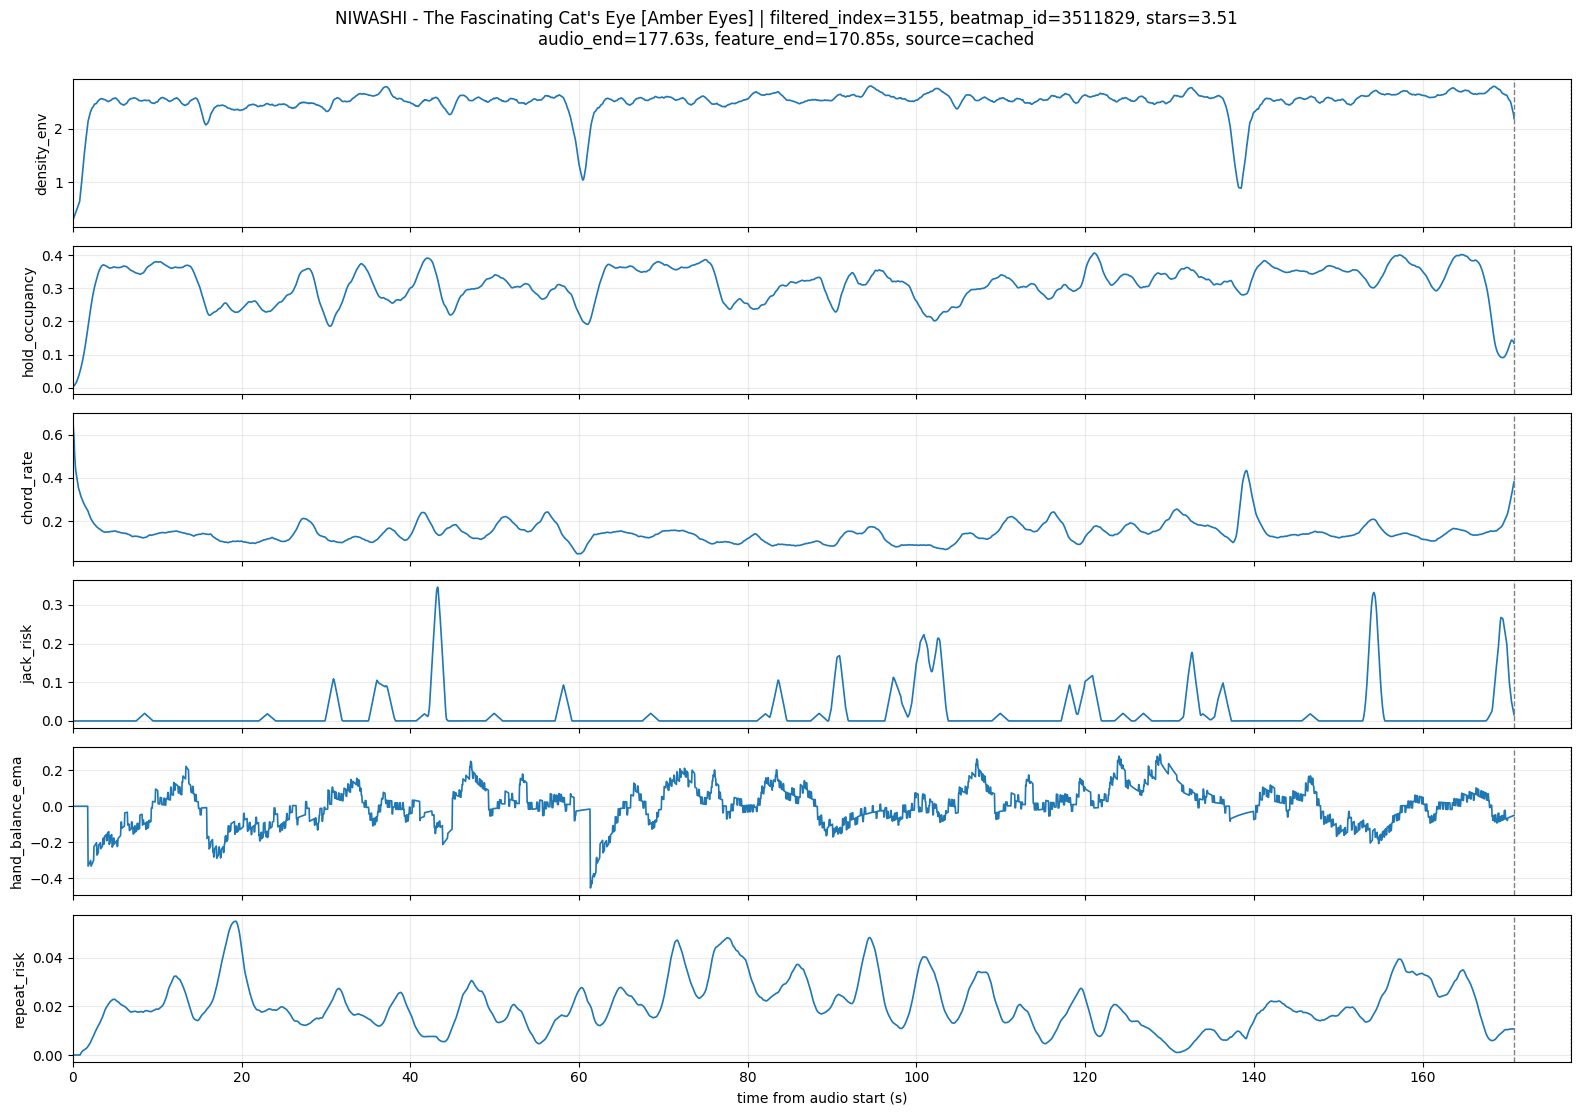

In [405]:
# Pure random matplotlib usage. Run this cell to render a random map plot.
def sample_random_beatmap(seed: int | None = None) -> pd.Series:
    """Pick one map uniformly from the cached feature metadata."""
    if metadata.empty:
        raise LookupError("metadata is empty")
    rng = np.random.default_rng(seed)
    return metadata.iloc[int(rng.integers(len(metadata)))]


RANDOM_SEED = None
RUN_RANDOM_EXAMPLE = True

random_row = sample_random_beatmap(seed=RANDOM_SEED)
display(random_row[[
    "filtered_index",
    "source_index",
    "beatmap_id",
    "difficulty",
    "artist",
    "title",
    "version",
    "duration_s",
    "grid_rows",
]].to_frame().T)

if RUN_RANDOM_EXAMPLE:
    show_beatmap_features(
        filtered_index=int(random_row["filtered_index"]),
        source="cached",
        layout="stacked",
        max_points=12_000,
    )
